## Preamble

In [1]:
vmin=490.8
vmax=1990

h=6

nz=259; nx=1111

dt=0.0018
nt=5554  #10 s

ntr=2220

In [16]:
import numpy as np
import matplotlib.pyplot as plt


z=np.arange(0,nz)*h
x=np.arange(0,nx)*h

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,title_colorbar=None,grid=True):
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],cmap=cmap,extent=extent,aspect='auto')
    cbar=plt.colorbar(location='right')
    cbar=cbar.ax.set_ylabel(title_colorbar)
    if grid==True: plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWD',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

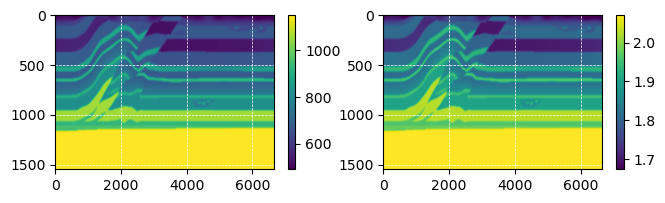

In [11]:
#plot
plt.figure(figsize=(12,2))
true=read('true',(3*nx,nz))

vp =true[:,:nx]
vs =true[:,nx:2*nx]
#rho=true[:,2*nx:]

rho = 0.31*vp**0.25

plt.subplot(1,3,1); imshow(vs, extent=(0,(nx-1)*h,(nz-1)*h,0))
plt.subplot(1,3,2); imshow(rho,extent=(0,(nx-1)*h,(nz-1)*h,0))

true=np.concatenate((vs.T,rho.T)).T
true.T.astype('float32').tofile('true_vsrho')

In [13]:
!cat setup_default_overthrust

MODEL_SIZE              '259  1111 1'
MODEL_SPACING           '6    6    1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vs rho'
MODEL_ATTRIBUTES_WRITE  'vs'
FILE_TOPO                none

IS_FREESURFACE          T

ACQUI_GEOMETRY          spread
FS                      '  0   166.5  0'
DS                      '  0   166.5  0'
NS                      39
FR                      '  0     0  0'
DR                      '  0     3  0'
NR                      2220

SCOMP                    vy
RCOMP                   'vy szy sxy'

NT           5554
DT           0.0018

WAVELET_TYPE	ricker


#############
## for FWI ##
#############
FILE_DATA_PREFIX    './res_obs/Ru_Shot'
NBATCH               39
WEIGHTING           'none'

FPEAK           6.54

PARAMETER           'vs:490.75:1148.93'

IF_PARA_SCAL         T

SMOOTHING            Laplacian
LAP_FRAC         '0.1 0.1 0.1'

#PRECO           'z^0'

JOB             gradient

#SNAPSHOT     'p vz'
#NSNAPSHOT    50

MAX_ITERATE     120
MAX_M

## Forward modeling w/ free surface

### SH

In [14]:
!cp setup_default_overthrust setup
!echo "NS    1" >> setup
!echo "FS           '3     0  0'" >> setup
!echo "FR           '3     0  0'" >> setup
!echo "SCOMP         vy" >> setup
!echo "RCOMP        'vy szy sxy'" >> setup
run(app='../../exe/fwd_SH_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 611432 Feb  2 08:59 ../../exe/fwd_SH_FDSG_O4_
 Git Commit: c77aefc
 Git Branch: SH
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/02/2026
System time: 09:10:03
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D SH wave propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diago

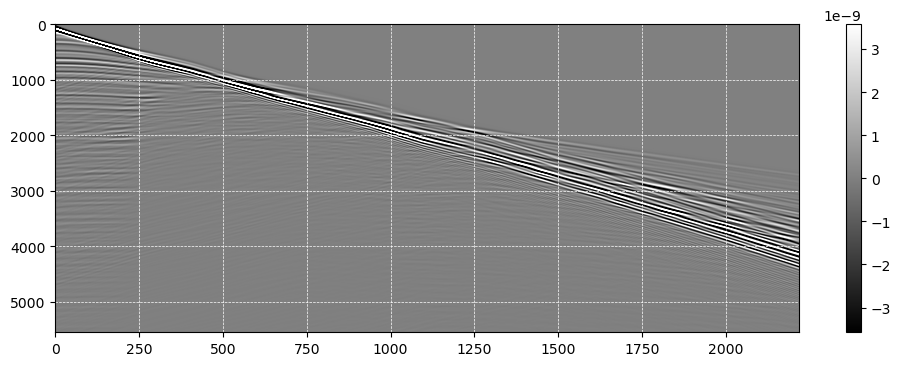

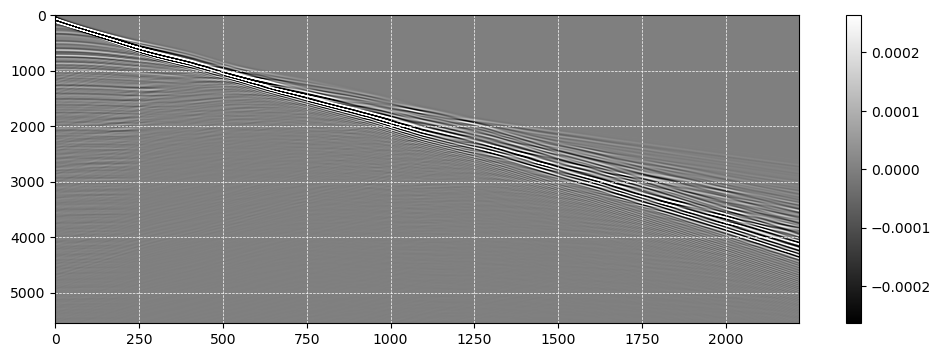

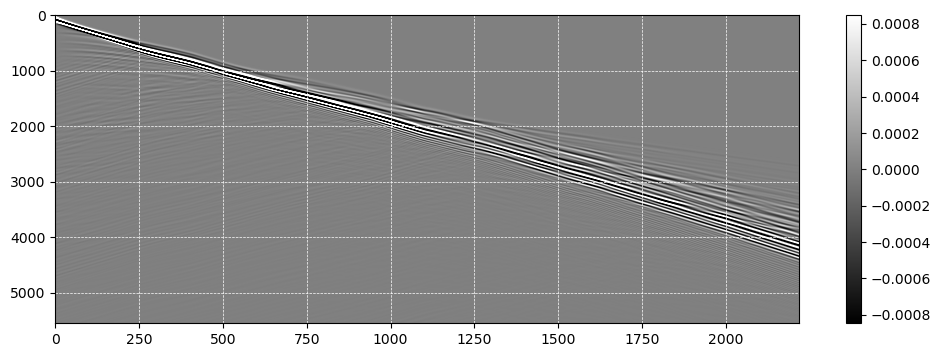

In [18]:
data=read_su('results/Ru_Shot0001.su',(3*ntr,nt))

plt.figure(figsize=(12,4))
imshow(data[:,:ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,ntr:2*ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,2*ntr:],perc=98,cmap='gray')

### AC

In [20]:
!cp setup_default_overthrust setup
!echo "MODEL_ATTRIBUTES   'vp rho'" >> setup
!echo "NS    1" >> setup
!echo "FS           '3     0  0'" >> setup
!echo "FR           '3     0  0'" >> setup
!echo "SCOMP         p" >> setup
!echo "RCOMP        'p vz vx'" >> setup
!echo "DIR_OUT       results_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 747256 Dec  8 10:10 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 07b5790
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/02/2026
System time: 09:14:42
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_AC
 Output directory:results_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress(Pressure) formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagon

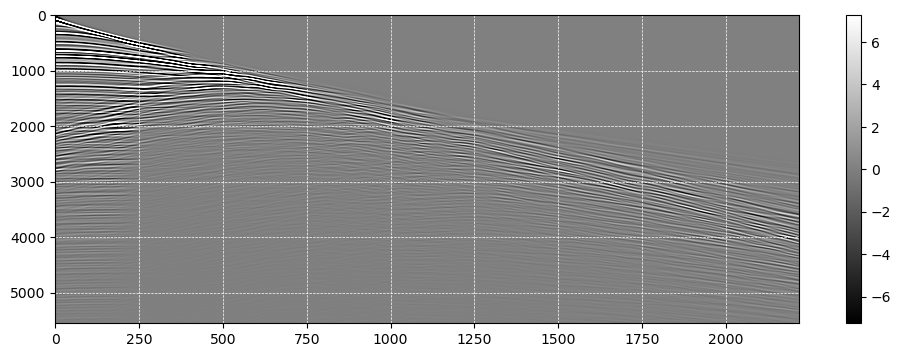

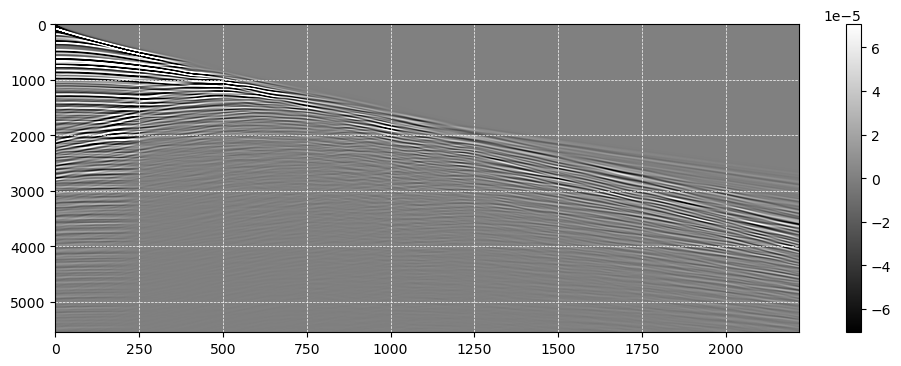

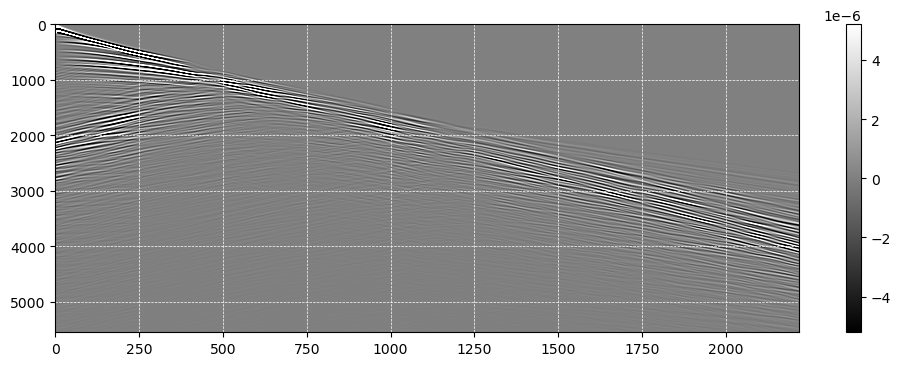

In [21]:
data=read_su('results_AC/Ru_Shot0001.su',(3*ntr,nt))

plt.figure(figsize=(12,4))
imshow(data[:,:ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,ntr:2*ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,2*ntr:],perc=98,cmap='gray')

### Compar

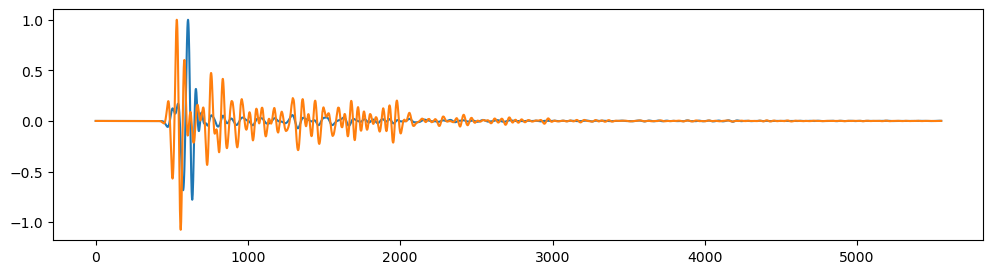

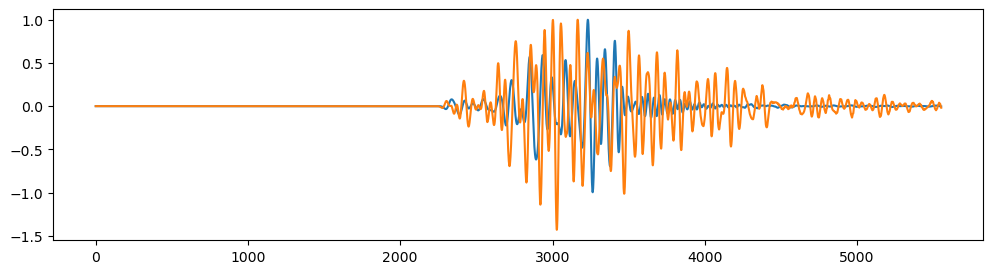

In [24]:
dataSH=read_su('results/Ru_Shot0001.su',   (3*ntr,nt))
dataAC=read_su('results_AC/Ru_Shot0001.su',(3*ntr,nt))

plt.figure(figsize=(12,3)); itr=250
plt.plot(dataSH[:,itr]/dataSH[:,itr].max())
plt.plot(dataAC[:,itr]/dataAC[:,itr].max())

plt.figure(figsize=(12,3)); itr=1750
plt.plot(dataSH[:,itr]/dataSH[:,itr].max())
plt.plot(dataAC[:,itr]/dataAC[:,itr].max())

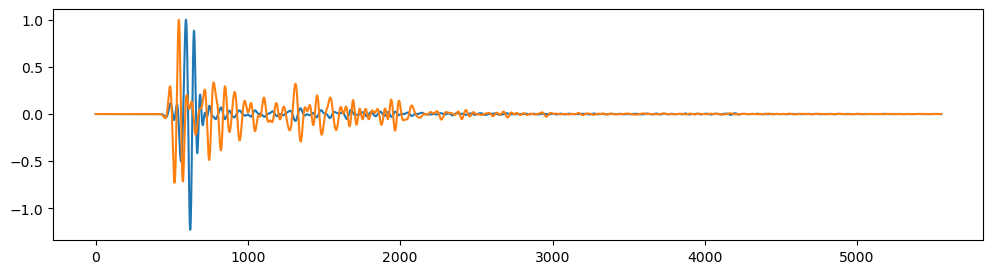

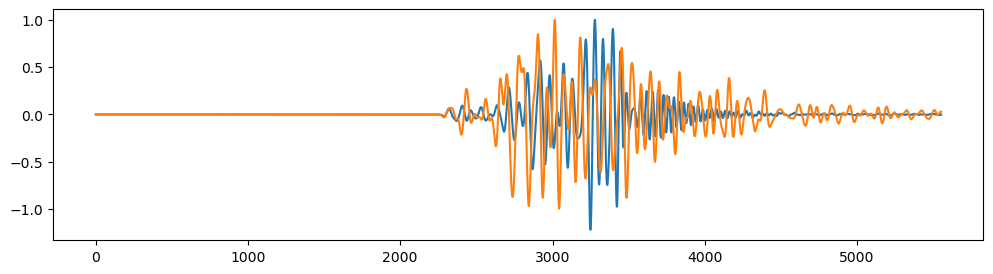

In [25]:
plt.figure(figsize=(12,3)); itr=250
plt.plot(dataSH[:,itr+ntr]/dataSH[:,itr+ntr].max())
plt.plot(dataAC[:,itr+ntr]/dataAC[:,itr+ntr].max())

plt.figure(figsize=(12,3)); itr=1750
plt.plot(dataSH[:,itr+ntr]/dataSH[:,itr+ntr].max())
plt.plot(dataAC[:,itr+ntr]/dataAC[:,itr+ntr].max())

## Forward modeling w/o free surface

### SH

In [26]:
!cp setup_default_overthrust setup
!echo "IS_FREESURFACE   F" >> setup
!echo "NS    1" >> setup
!echo "FS           '3     0  0'" >> setup
!echo "FR           '3     0  0'" >> setup
!echo "SCOMP         vy" >> setup
!echo "RCOMP        'vy szy sxy'" >> setup
run(app='../../exe/fwd_SH_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 611432 Feb  2 08:59 ../../exe/fwd_SH_FDSG_O4_
 Git Commit: c77aefc
 Git Branch: SH
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/02/2026
System time: 09:19:25
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D SH wave propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diago

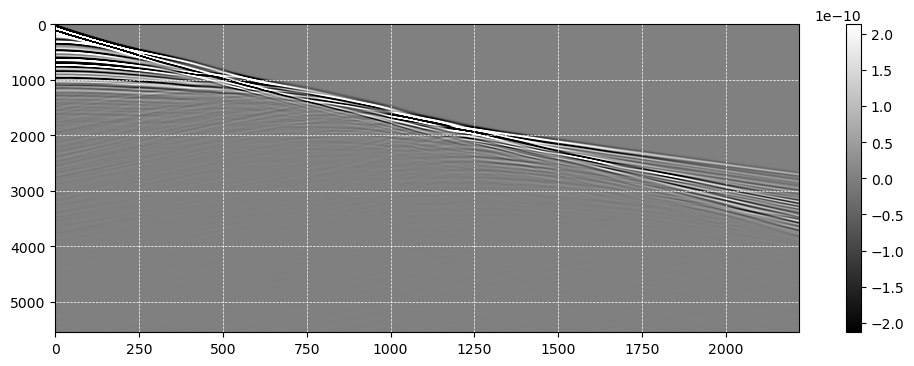

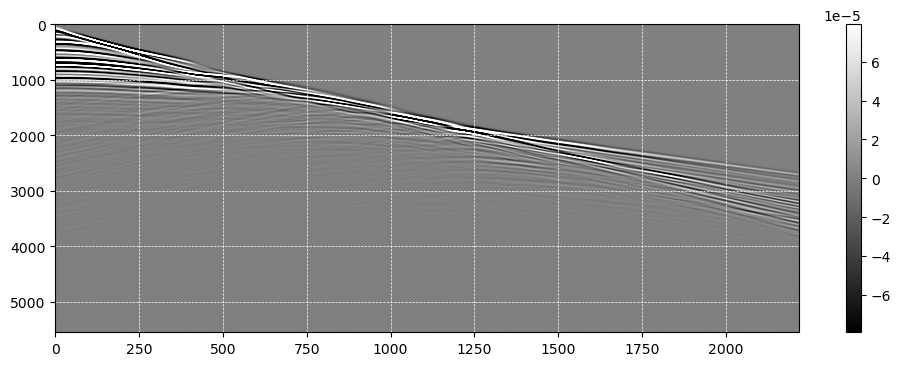

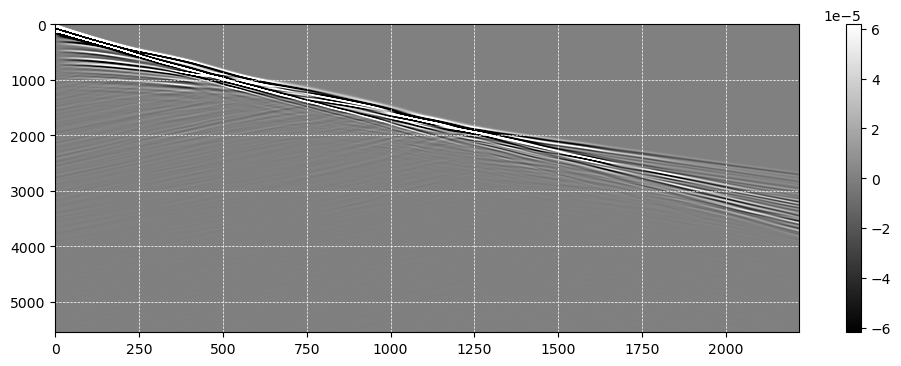

In [27]:
data=read_su('results/Ru_Shot0001.su',(3*ntr,nt))

plt.figure(figsize=(12,4))
imshow(data[:,:ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,ntr:2*ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,2*ntr:],perc=98,cmap='gray')

### AC

In [28]:
!cp setup_default_overthrust setup
!echo "MODEL_ATTRIBUTES   'vp rho'" >> setup
!echo "IS_FREESURFACE   F" >> setup
!echo "NS    1" >> setup
!echo "FS           '3     0  0'" >> setup
!echo "FR           '3     0  0'" >> setup
!echo "SCOMP         p" >> setup
!echo "RCOMP        'p vz vx'" >> setup
!echo "DIR_OUT       results_AC" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_FreeSurface
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 747256 Dec  8 10:10 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 07b5790
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 02/02/2026
System time: 09:19:46
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_AC
 Output directory:results_AC/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress(Pressure) formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagon

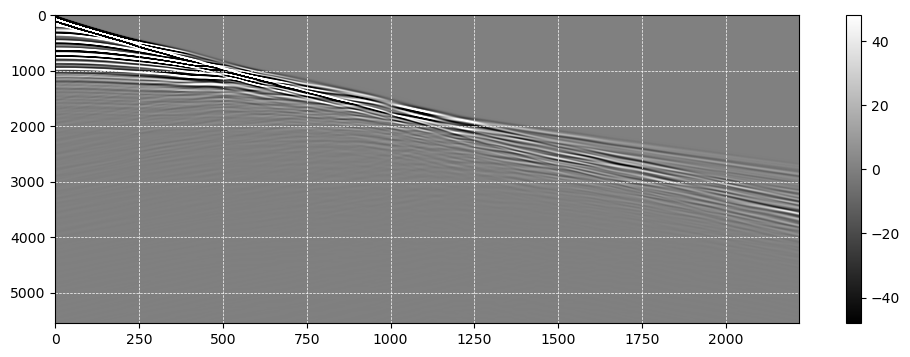

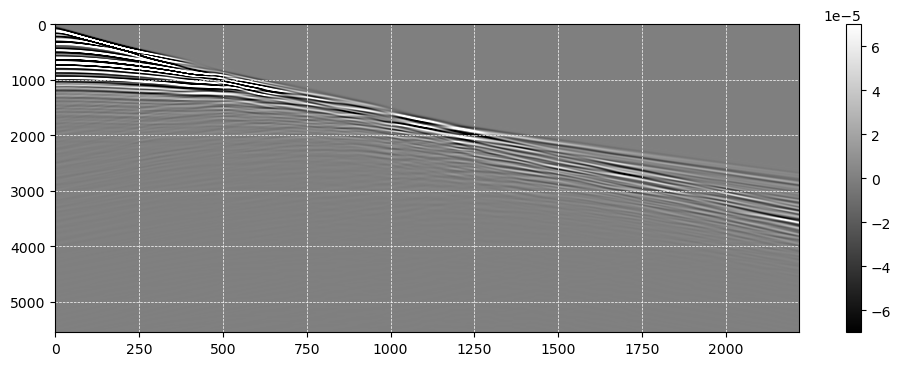

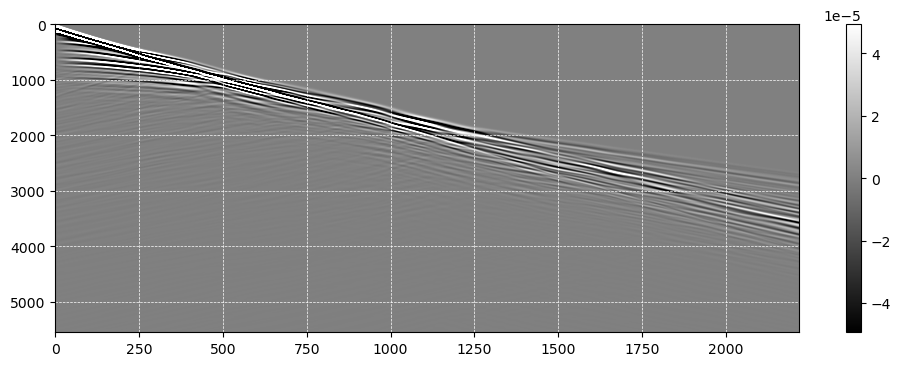

In [29]:
data=read_su('results_AC/Ru_Shot0001.su',(3*ntr,nt))

plt.figure(figsize=(12,4))
imshow(data[:,:ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,ntr:2*ntr],perc=98,cmap='gray')

plt.figure(figsize=(12,4))
imshow(data[:,2*ntr:],perc=98,cmap='gray')

### Compar

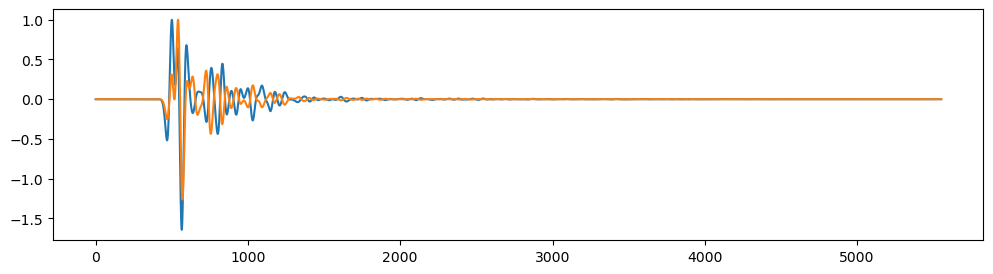

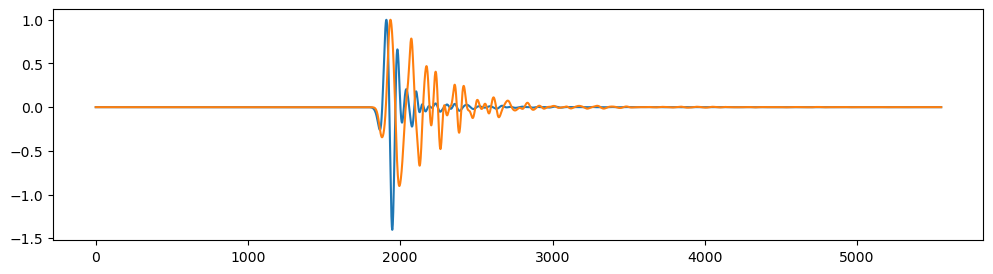

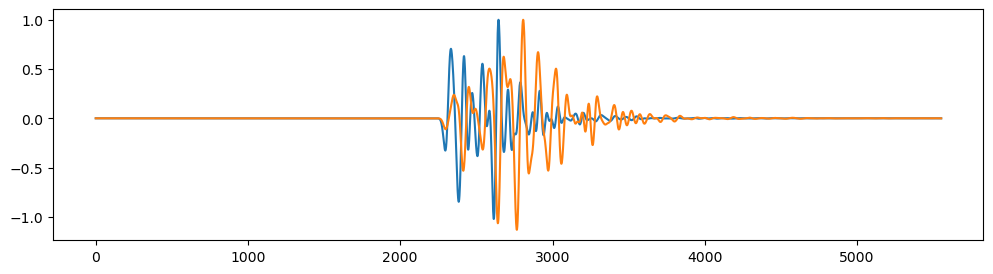

In [32]:
dataSH=read_su('results/Ru_Shot0001.su',   (3*ntr,nt))
dataAC=read_su('results_AC/Ru_Shot0001.su',(3*ntr,nt))

plt.figure(figsize=(12,3)); itr=250
plt.plot(dataSH[:,itr]/dataSH[:,itr].max())
plt.plot(dataAC[:,itr]/dataAC[:,itr].max())

plt.figure(figsize=(12,3)); itr=1250
plt.plot(dataSH[:,itr]/dataSH[:,itr].max())
plt.plot(dataAC[:,itr]/dataAC[:,itr].max())

plt.figure(figsize=(12,3)); itr=1750
plt.plot(dataSH[:,itr]/dataSH[:,itr].max())
plt.plot(dataAC[:,itr]/dataAC[:,itr].max())

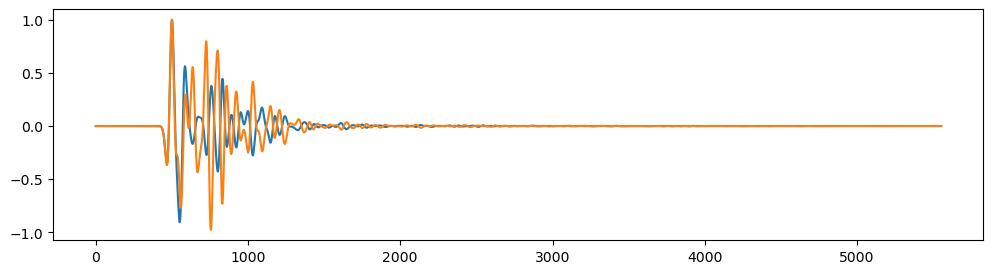

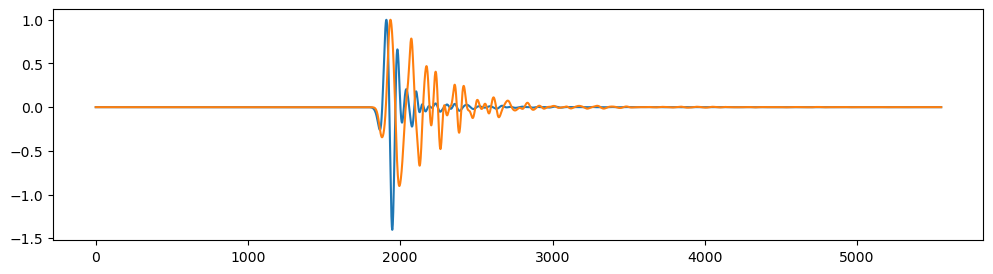

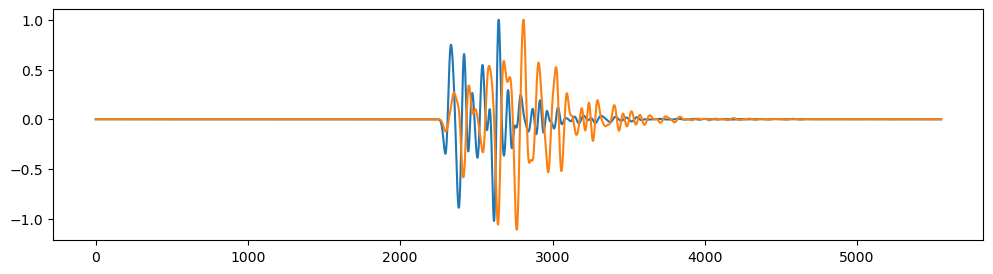

In [33]:
plt.figure(figsize=(12,3)); itr=250
plt.plot(dataSH[:,itr+ntr]/dataSH[:,itr+ntr].max())
plt.plot(dataAC[:,itr+ntr]/dataAC[:,itr+ntr].max())

plt.figure(figsize=(12,3)); itr=1250
plt.plot(dataSH[:,itr]/dataSH[:,itr].max())
plt.plot(dataAC[:,itr]/dataAC[:,itr].max())

plt.figure(figsize=(12,3)); itr=1750
plt.plot(dataSH[:,itr+ntr]/dataSH[:,itr+ntr].max())
plt.plot(dataAC[:,itr+ntr]/dataAC[:,itr+ntr].max())